In [1]:
# Sales Forecasting and Revenue Trend Analysis
# Project setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

project_root = Path.cwd().parent
raw_path = project_root / "data" / "raw"
cleaned_path = project_root / "data" / "cleaned"
image_path = project_root / "images"

raw_path.mkdir(parents=True, exist_ok=True)
cleaned_path.mkdir(parents=True, exist_ok=True)
image_path.mkdir(parents=True, exist_ok=True)

print("Project folders ready")
print("Raw data folder:", raw_path)
print("Cleaned data folder:", cleaned_path)
print("Images folder:", image_path)

Project folders ready
Raw data folder: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/raw
Cleaned data folder: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/cleaned
Images folder: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/images


In [2]:
# Create an 8,574 row sales transaction dataset

num_rows = 8574

date_range = pd.date_range(start="2023-01-01", end="2025-12-31", freq="D")

regions = ["South", "West", "Midwest", "Northeast"]
product_categories = ["Technology", "Furniture", "Office Supplies", "Software", "Services"]
sales_channels = ["Online", "Retail", "Partner", "Direct Sales"]
customer_segments = ["Small Business", "Mid Market", "Enterprise", "Consumer"]

sales_data = pd.DataFrame({
    "transaction_id": np.arange(1, num_rows + 1),
    "order_date": np.random.choice(date_range, num_rows),
    "region": np.random.choice(regions, num_rows, p=[0.32, 0.27, 0.21, 0.20]),
    "product_category": np.random.choice(product_categories, num_rows, p=[0.28, 0.18, 0.20, 0.19, 0.15]),
    "sales_channel": np.random.choice(sales_channels, num_rows, p=[0.42, 0.24, 0.19, 0.15]),
    "customer_segment": np.random.choice(customer_segments, num_rows, p=[0.35, 0.30, 0.20, 0.15]),
    "units_sold": np.random.randint(1, 12, num_rows),
    "unit_price": np.random.normal(loc=185, scale=55, size=num_rows).round(2),
    "discount_rate": np.random.choice([0, 0.05, 0.10, 0.15, 0.20], num_rows, p=[0.45, 0.25, 0.17, 0.09, 0.04])
})

sales_data["unit_price"] = sales_data["unit_price"].clip(lower=25)

sales_data["gross_revenue"] = sales_data["units_sold"] * sales_data["unit_price"]
sales_data["discount_amount"] = sales_data["gross_revenue"] * sales_data["discount_rate"]
sales_data["net_revenue"] = sales_data["gross_revenue"] - sales_data["discount_amount"]

# Add seasonal lift so the data has more realistic business patterns
sales_data["month"] = pd.to_datetime(sales_data["order_date"]).dt.month
sales_data["seasonality_multiplier"] = np.where(
    sales_data["month"].isin([10, 11, 12]),
    1.25,
    np.where(sales_data["month"].isin([6, 7, 8]), 1.10, 1.00)
)

sales_data["net_revenue"] = (sales_data["net_revenue"] * sales_data["seasonality_multiplier"]).round(2)
sales_data["gross_revenue"] = sales_data["gross_revenue"].round(2)
sales_data["discount_amount"] = sales_data["discount_amount"].round(2)

raw_file = raw_path / "sales_transactions_8574_rows.csv"
sales_data.to_csv(raw_file, index=False)

print("Raw sales dataset created")
print("Rows:", len(sales_data))
print("File:", raw_file)

sales_data.head()

Raw sales dataset created
Rows: 8574
File: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/raw/sales_transactions_8574_rows.csv


,transaction_id,order_date,region,product_category,sales_channel,customer_segment,units_sold,unit_price,discount_rate,gross_revenue,discount_amount,net_revenue,month,seasonality_multiplier
0,1,2025-05-10,South,Office Supplies,Online,Small Business,8,164.42,0.00,1315.36,0.00,1315.36,5,1.00
1,2,2025-12-31,South,Software,Partner,Mid Market,5,185.39,0.00,926.95,0.00,1158.69,12,1.25
2,3,2025-11-10,West,Office Supplies,Online,Mid Market,1,131.54,0.00,131.54,0.00,164.42,11,1.25
3,4,2023-05-02,South,Office Supplies,Partner,Small Business,4,121.42,0.05,485.68,24.28,461.40,5,1.00
4,5,2024-04-11,West,Furniture,Partner,Mid Market,11,164.26,0.05,1806.86,90.34,1716.52,4,1.00


In [3]:
# Load the raw dataset and create monthly sales summary

df = pd.read_csv(raw_file)

df["order_date"] = pd.to_datetime(df["order_date"])
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_sales = (
    df
    .groupby("order_month", as_index=False)
    .agg(
        total_transactions=("transaction_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_gross_revenue=("gross_revenue", "sum"),
        total_discount_amount=("discount_amount", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        average_order_value=("net_revenue", "mean")
    )
    .sort_values("order_month")
)

monthly_sales["total_gross_revenue"] = monthly_sales["total_gross_revenue"].round(2)
monthly_sales["total_discount_amount"] = monthly_sales["total_discount_amount"].round(2)
monthly_sales["total_net_revenue"] = monthly_sales["total_net_revenue"].round(2)
monthly_sales["average_order_value"] = monthly_sales["average_order_value"].round(2)

print("Monthly sales summary created")
print("Months:", len(monthly_sales))

monthly_sales.head()

Monthly sales summary created
Months: 36


,order_month,total_transactions,total_units_sold,total_gross_revenue,total_discount_amount,total_net_revenue,average_order_value
0,2023-01,242,1435,264511.48,12947.37,251564.13,1039.52
1,2023-02,198,1167,217547.70,9270.17,208277.61,1051.91
2,2023-03,230,1358,255070.83,13946.02,241124.80,1048.37
3,2023-04,219,1237,223610.52,12207.62,211402.92,965.31
4,2023-05,253,1441,270628.46,14684.39,255944.05,1011.64


In [4]:
# Feature engineering for forecasting and advanced trend analysis

df = pd.read_csv(raw_file)

df["order_date"] = pd.to_datetime(df["order_date"])
df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

# Monthly revenue summary
monthly_sales = (
    df
    .groupby("order_month", as_index=False)
    .agg(
        total_transactions=("transaction_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_gross_revenue=("gross_revenue", "sum"),
        total_discount_amount=("discount_amount", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        average_order_value=("net_revenue", "mean")
    )
    .sort_values("order_month")
)

# Add time series features
monthly_sales["month_number"] = np.arange(1, len(monthly_sales) + 1)
monthly_sales["year"] = monthly_sales["order_month"].dt.year
monthly_sales["month"] = monthly_sales["order_month"].dt.month
monthly_sales["quarter"] = monthly_sales["order_month"].dt.quarter

# Moving averages
monthly_sales["revenue_3_month_moving_avg"] = (
    monthly_sales["total_net_revenue"]
    .rolling(window=3)
    .mean()
)

monthly_sales["revenue_6_month_moving_avg"] = (
    monthly_sales["total_net_revenue"]
    .rolling(window=6)
    .mean()
)

# Month over month growth
monthly_sales["month_over_month_growth"] = (
    monthly_sales["total_net_revenue"]
    .pct_change()
    .round(4)
)

# Lag features for forecasting
monthly_sales["revenue_lag_1"] = monthly_sales["total_net_revenue"].shift(1)
monthly_sales["revenue_lag_2"] = monthly_sales["total_net_revenue"].shift(2)
monthly_sales["revenue_lag_3"] = monthly_sales["total_net_revenue"].shift(3)

monthly_sales.head(10)

,order_month,total_transactions,total_units_sold,total_gross_revenue,total_discount_amount,total_net_revenue,average_order_value,month_number,year,month,quarter,revenue_3_month_moving_avg,revenue_6_month_moving_avg,month_over_month_growth,revenue_lag_1,revenue_lag_2,revenue_lag_3
0,2023-01-01,242,1435,264511.48,12947.37,251564.13,1039.521198,1,2023,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-01,198,1167,217547.70,9270.17,208277.61,1051.907121,2,2023,2,1,NaN,NaN,-0.1721,251564.13,NaN,NaN
2,2023-03-01,230,1358,255070.83,13946.02,241124.80,1048.368696,3,2023,3,1,233655.513333,NaN,0.1577,208277.61,251564.13,NaN
3,2023-04-01,219,1237,223610.52,12207.62,211402.92,965.310137,4,2023,4,2,220268.443333,NaN,-0.1233,241124.80,208277.61,251564.13
4,2023-05-01,253,1441,270628.46,14684.39,255944.05,1011.636561,5,2023,5,2,236157.256667,NaN,0.2107,211402.92,241124.80,208277.61
5,2023-06-01,220,1322,240123.16,12554.64,250325.42,1137.842818,6,2023,6,2,239224.130000,236439.821667,-0.0220,255944.05,211402.92,241124.80
6,2023-07-01,243,1526,288526.22,14490.44,301439.51,1240.491811,7,2023,7,3,269236.326667,244752.385000,0.2042,250325.42,255944.05,211402.92
7,2023-08-01,260,1544,282600.64,14540.56,294866.09,1134.100346,8,2023,8,3,282210.340000,259183.798333,-0.0218,301439.51,250325.42,255944.05
8,2023-09-01,226,1289,248740.77,14301.77,234439.01,1037.340752,9,2023,9,3,276914.870000,258069.500000,-0.2049,294866.09,301439.51,250325.42
9,2023-10-01,215,1381,256434.60,14234.42,302750.27,1408.140791,10,2023,10,4,277351.790000,273294.058333,0.2914,234439.01,294866.09,301439.51


In [5]:
print("Raw transaction rows:", len(df))
print("Monthly summary rows:", len(monthly_sales))
print("Date range:", df["order_date"].min(), "to", df["order_date"].max())
print("Total net revenue:", "${:,.2f}".format(df["net_revenue"].sum()))

monthly_sales.tail()

Raw transaction rows: 8574
Monthly summary rows: 36
Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Total net revenue: $9,825,214.87


,order_month,total_transactions,total_units_sold,total_gross_revenue,total_discount_amount,total_net_revenue,average_order_value,month_number,year,month,quarter,revenue_3_month_moving_avg,revenue_6_month_moving_avg,month_over_month_growth,revenue_lag_1,revenue_lag_2,revenue_lag_3
31,2025-08-01,235,1353,258357.02,12353.53,270603.90,1151.505957,32,2025,8,3,291467.530000,272410.648333,-0.1361,313234.32,290564.37,240543.44
32,2025-09-01,250,1519,285531.69,15973.63,269558.07,1078.232280,33,2025,9,3,284465.430000,277501.943333,-0.0039,270603.90,313234.32,290564.37
33,2025-10-01,234,1378,258221.36,13310.03,306139.22,1308.287265,34,2025,10,4,282100.396667,281773.886667,0.1357,269558.07,270603.90,313234.32
34,2025-11-01,220,1337,241778.89,14190.04,284485.96,1293.118000,35,2025,11,4,286727.750000,289097.640000,-0.0707,306139.22,269558.07,270603.90
35,2025-12-01,253,1493,272909.67,13320.74,324486.16,1282.553992,36,2025,12,4,305037.113333,294751.271667,0.1406,284485.96,306139.22,269558.07


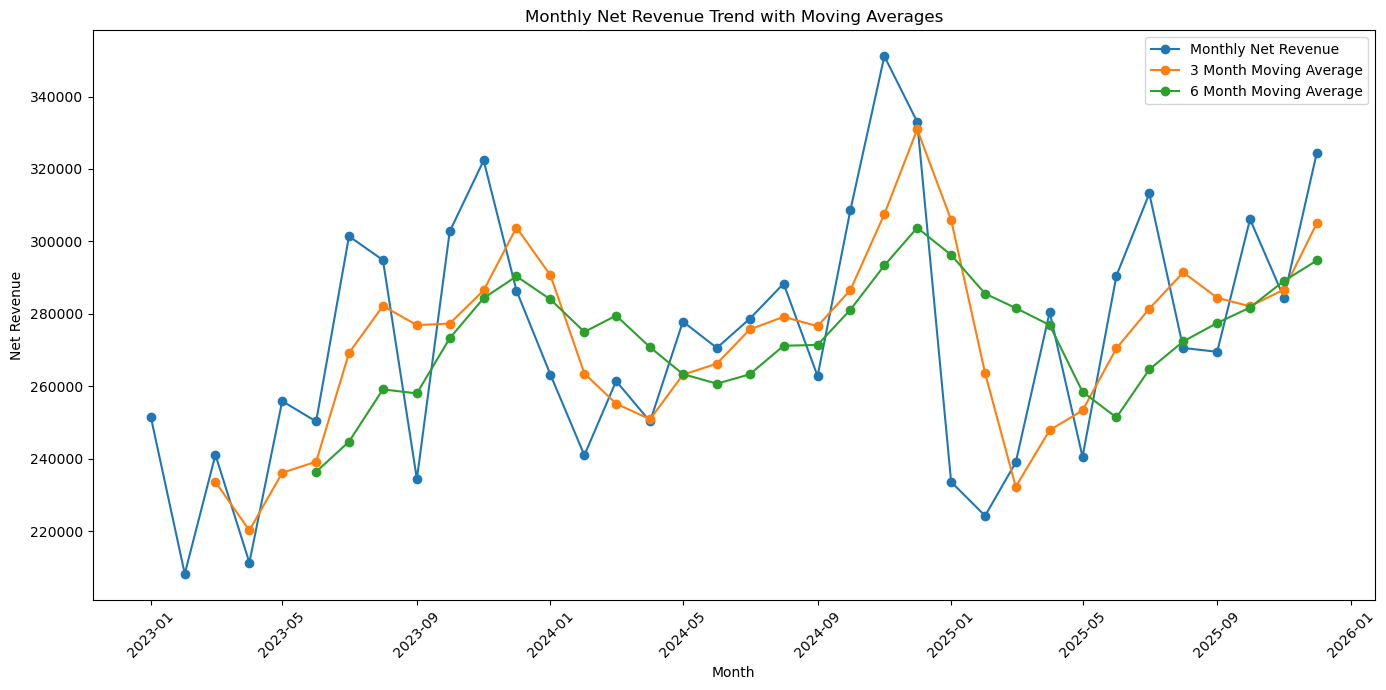

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/images/monthly_revenue_trend_with_moving_averages.png


In [6]:
# Advanced visualizations for sales forecasting project

# 1. Monthly net revenue trend with moving averages
plt.figure(figsize=(14, 7))
plt.plot(monthly_sales["order_month"], monthly_sales["total_net_revenue"], marker="o", label="Monthly Net Revenue")
plt.plot(monthly_sales["order_month"], monthly_sales["revenue_3_month_moving_avg"], marker="o", label="3 Month Moving Average")
plt.plot(monthly_sales["order_month"], monthly_sales["revenue_6_month_moving_avg"], marker="o", label="6 Month Moving Average")
plt.title("Monthly Net Revenue Trend with Moving Averages")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

monthly_trend_path = image_path / "monthly_revenue_trend_with_moving_averages.png"
plt.savefig(monthly_trend_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", monthly_trend_path)

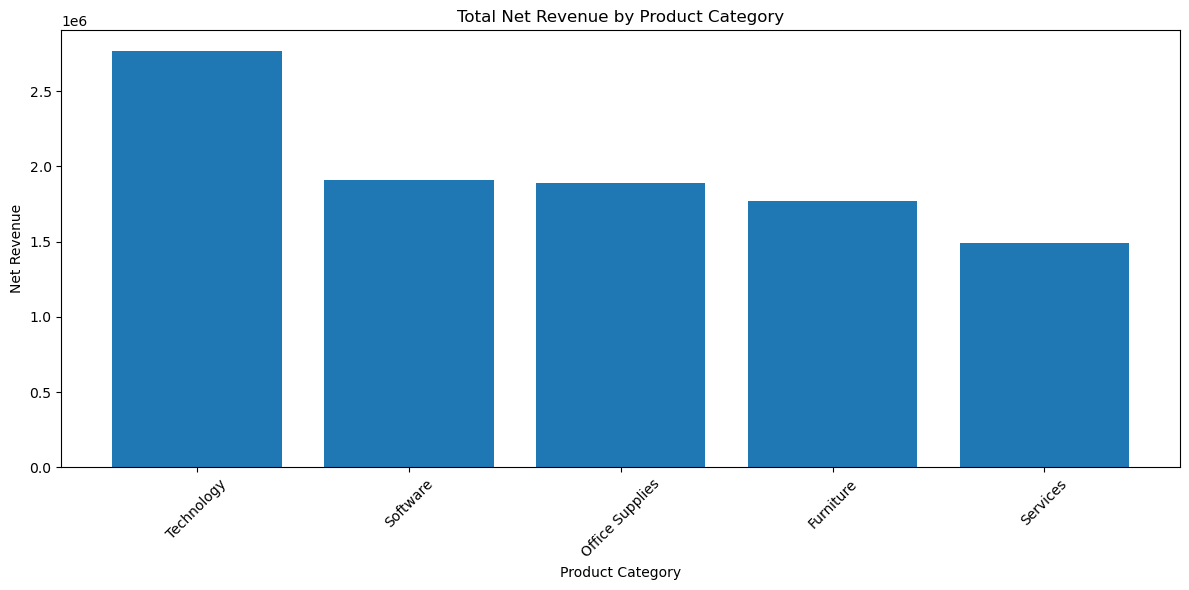

,product_category,total_transactions,total_units_sold,total_net_revenue,average_order_value
4,Technology,2437,14622,2766449.46,1135.186483
3,Software,1638,9958,1906799.98,1164.102552
1,Office Supplies,1654,9785,1888444.75,1141.744105
0,Furniture,1551,9233,1773118.14,1143.209632
2,Services,1294,7777,1490402.54,1151.779397


In [7]:
# 2. Revenue by product category

category_summary = (
    df
    .groupby("product_category", as_index=False)
    .agg(
        total_transactions=("transaction_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        average_order_value=("net_revenue", "mean")
    )
    .sort_values("total_net_revenue", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(category_summary["product_category"], category_summary["total_net_revenue"])
plt.title("Total Net Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

category_path = image_path / "revenue_by_product_category.png"
plt.savefig(category_path, dpi=300, bbox_inches="tight")
plt.show()

category_summary

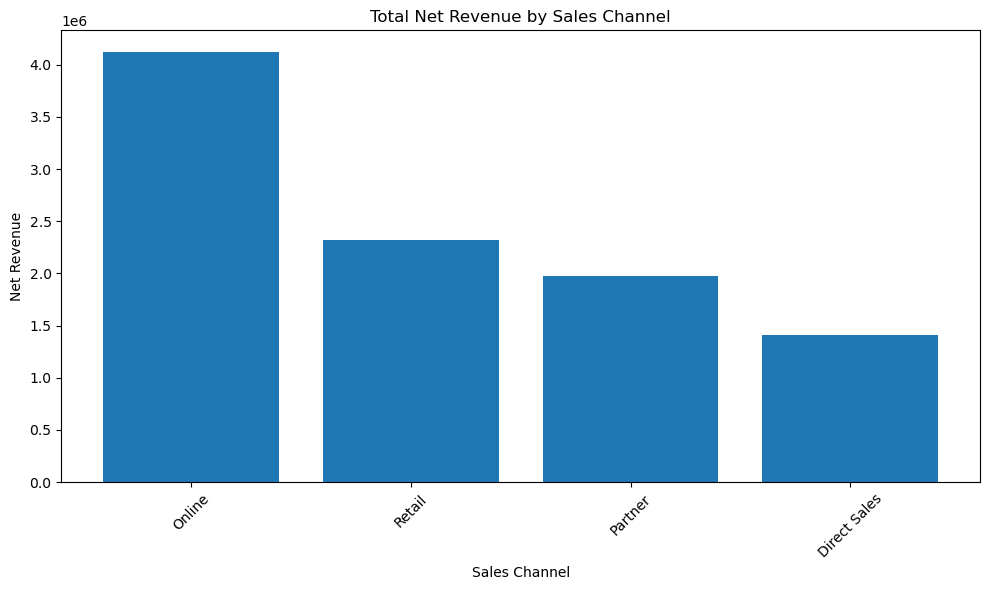

,sales_channel,total_transactions,total_units_sold,total_net_revenue,average_order_value
1,Online,3586,21510,4122438.06,1149.592320
3,Retail,2012,12195,2322503.65,1154.325870
2,Partner,1713,10338,1974016.93,1152.374156
0,Direct Sales,1263,7332,1406256.23,1113.425360


In [8]:
# 3. Revenue by sales channel

channel_summary = (
    df
    .groupby("sales_channel", as_index=False)
    .agg(
        total_transactions=("transaction_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        average_order_value=("net_revenue", "mean")
    )
    .sort_values("total_net_revenue", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(channel_summary["sales_channel"], channel_summary["total_net_revenue"])
plt.title("Total Net Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

channel_path = image_path / "revenue_by_sales_channel.png"
plt.savefig(channel_path, dpi=300, bbox_inches="tight")
plt.show()

channel_summary

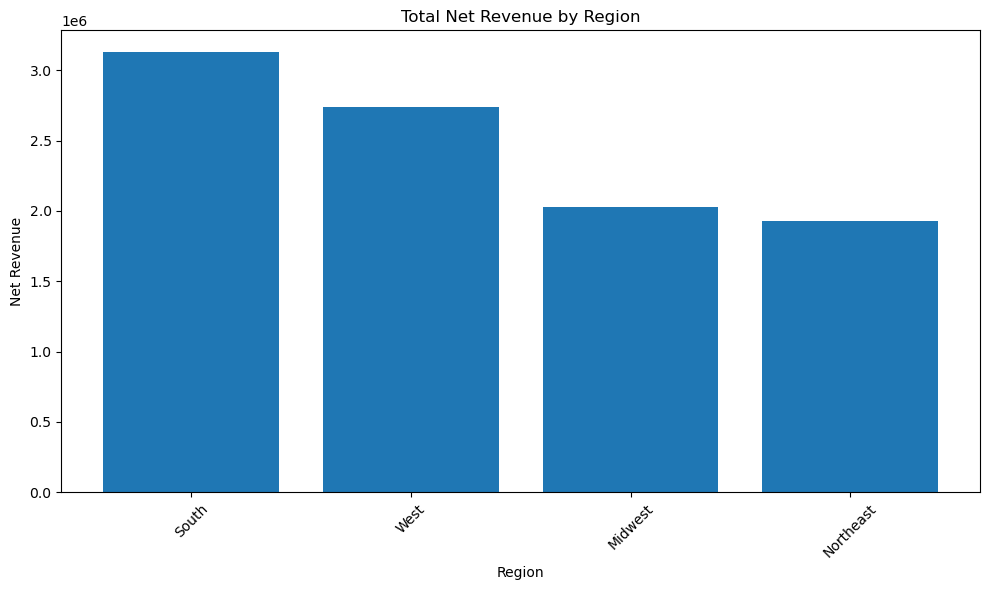

,region,total_transactions,total_units_sold,total_net_revenue,average_order_value
2,South,2722,16190,3127542.49,1148.986954
3,West,2365,14430,2741822.73,1159.333078
0,Midwest,1792,10675,2029870.71,1132.740352
1,Northeast,1695,10080,1925978.94,1136.270761


In [9]:
# 4. Revenue by region

region_summary = (
    df
    .groupby("region", as_index=False)
    .agg(
        total_transactions=("transaction_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        average_order_value=("net_revenue", "mean")
    )
    .sort_values("total_net_revenue", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(region_summary["region"], region_summary["total_net_revenue"])
plt.title("Total Net Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

region_path = image_path / "revenue_by_region.png"
plt.savefig(region_path, dpi=300, bbox_inches="tight")
plt.show()

region_summary

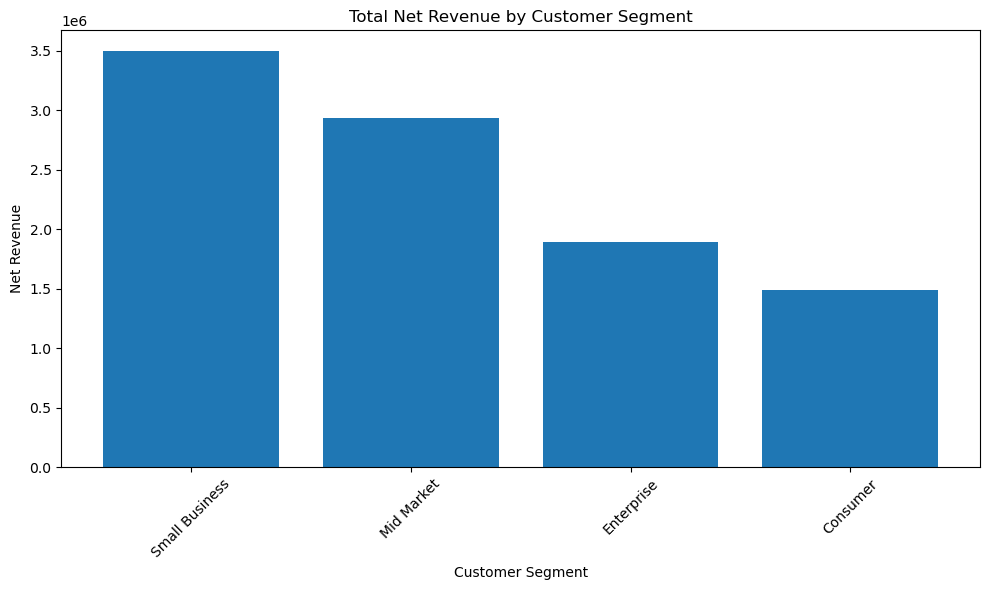

,customer_segment,total_transactions,total_units_sold,total_net_revenue,average_order_value
3,Small Business,3021,18303,3498350.02,1158.010599
2,Mid Market,2603,15306,2938932.91,1129.056055
1,Enterprise,1660,10036,1893151.32,1140.452602
0,Consumer,1290,7730,1494780.62,1158.744667


In [10]:
# 5. Revenue by customer segment

segment_summary = (
    df
    .groupby("customer_segment", as_index=False)
    .agg(
        total_transactions=("transaction_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        average_order_value=("net_revenue", "mean")
    )
    .sort_values("total_net_revenue", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(segment_summary["customer_segment"], segment_summary["total_net_revenue"])
plt.title("Total Net Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

segment_path = image_path / "revenue_by_customer_segment.png"
plt.savefig(segment_path, dpi=300, bbox_inches="tight")
plt.show()

segment_summary

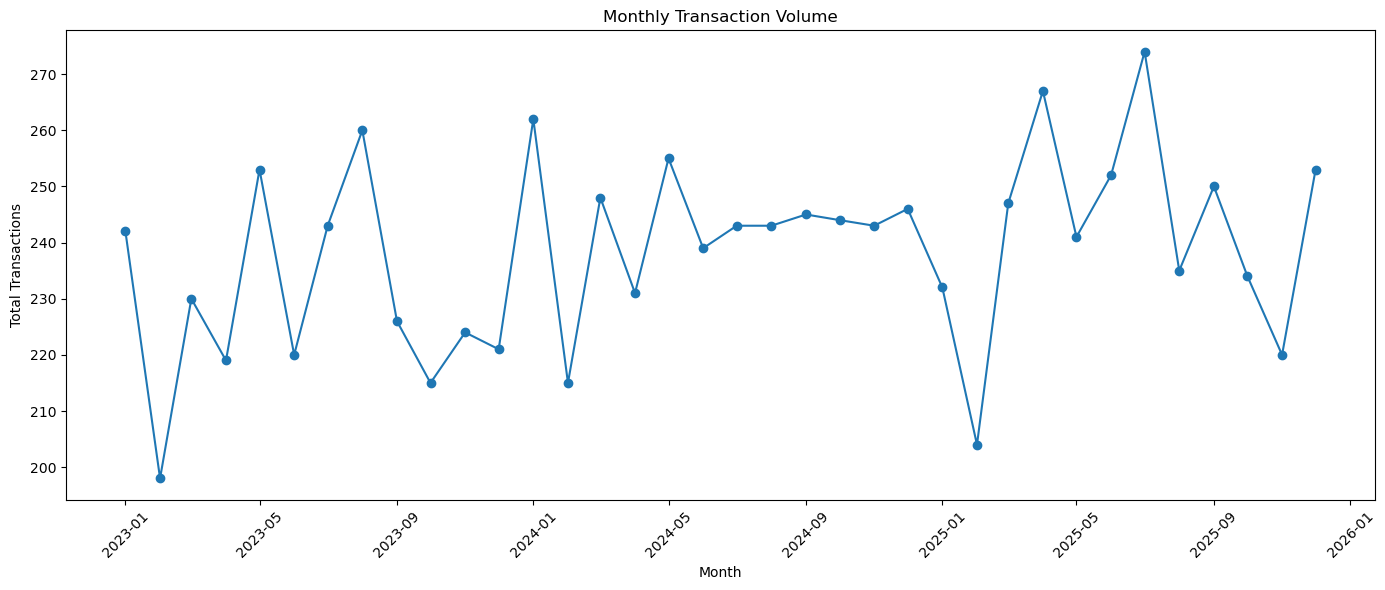

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/images/monthly_transaction_volume.png


In [11]:
# 6. Monthly transaction volume

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales["order_month"], monthly_sales["total_transactions"], marker="o")
plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Total Transactions")
plt.xticks(rotation=45)
plt.tight_layout()

transaction_volume_path = image_path / "monthly_transaction_volume.png"
plt.savefig(transaction_volume_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", transaction_volume_path)

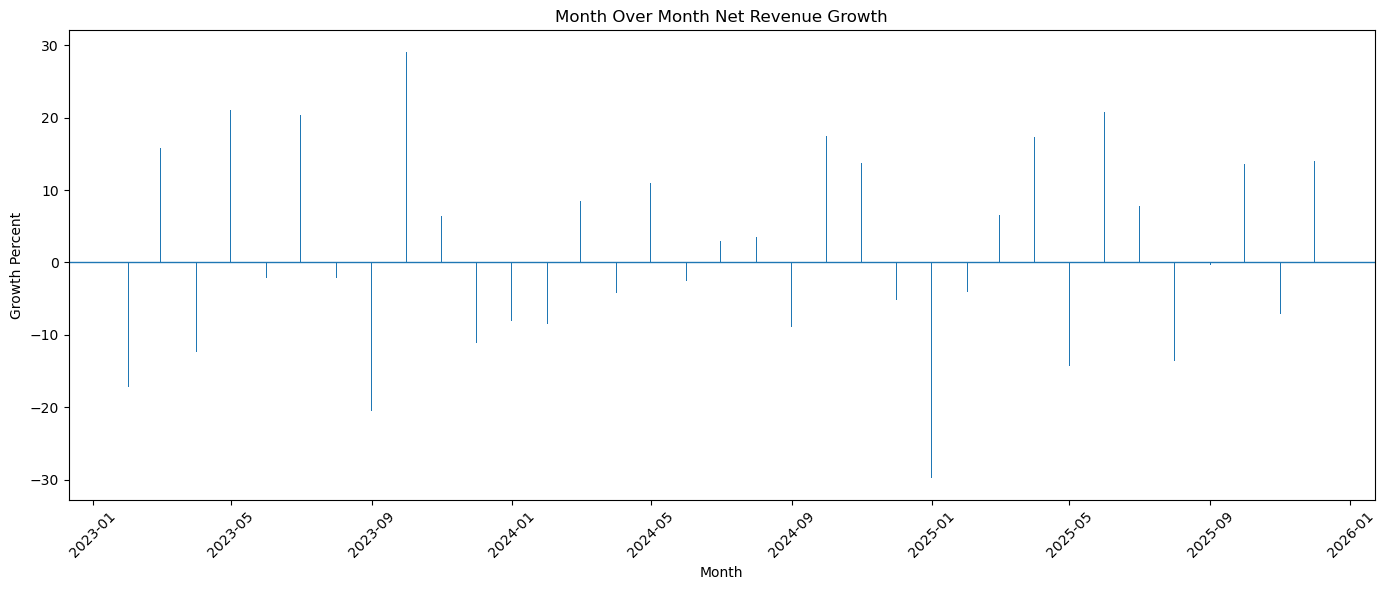

,order_month,total_net_revenue,growth_percent
1,2023-02-01,208277.61,-17.21
2,2023-03-01,241124.80,15.77
3,2023-04-01,211402.92,-12.33
4,2023-05-01,255944.05,21.07
5,2023-06-01,250325.42,-2.20


In [12]:
# 7. Month over month revenue growth

growth_data = monthly_sales.dropna(subset=["month_over_month_growth"]).copy()
growth_data["growth_percent"] = growth_data["month_over_month_growth"] * 100

plt.figure(figsize=(14, 6))
plt.bar(growth_data["order_month"], growth_data["growth_percent"])
plt.axhline(0, linewidth=1)
plt.title("Month Over Month Net Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Growth Percent")
plt.xticks(rotation=45)
plt.tight_layout()

growth_path = image_path / "month_over_month_revenue_growth.png"
plt.savefig(growth_path, dpi=300, bbox_inches="tight")
plt.show()

growth_data[["order_month", "total_net_revenue", "growth_percent"]].head()

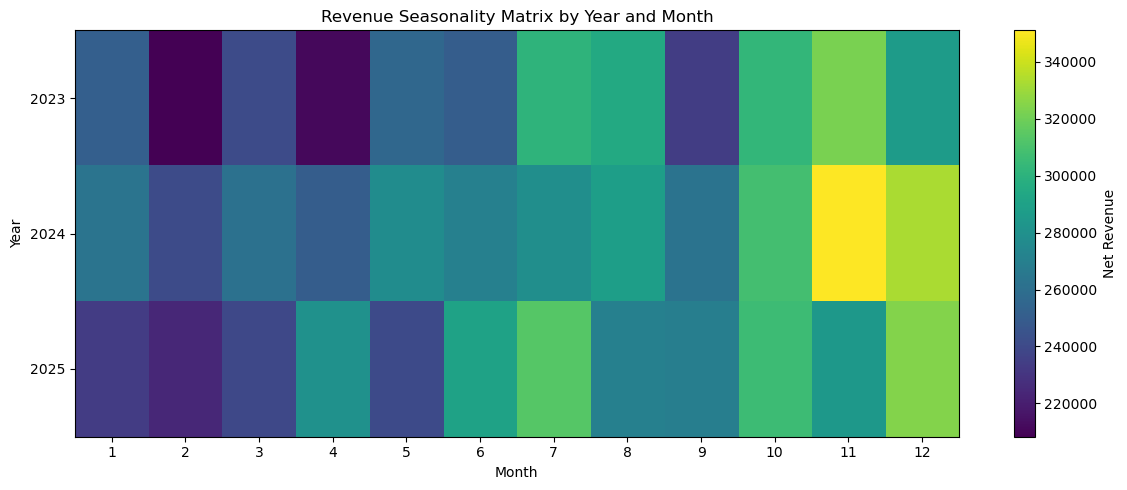

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,251564.13,208277.61,241124.80,211402.92,255944.05,250325.42,301439.51,294866.09,234439.01,302750.27,322350.82,286422.87
2024,263242.46,241006.64,261476.95,250322.14,277895.49,270616.68,278646.08,288374.44,262832.82,308676.83,351118.60,333016.34
2025,233653.42,224295.18,239010.30,280507.56,240543.44,290564.37,313234.32,270603.90,269558.07,306139.22,284485.96,324486.16


In [13]:
# 8. Revenue seasonality matrix by year and month

seasonality_matrix = monthly_sales.pivot_table(
    index="year",
    columns="month",
    values="total_net_revenue",
    aggfunc="sum"
)

plt.figure(figsize=(12, 5))
plt.imshow(seasonality_matrix, aspect="auto")
plt.title("Revenue Seasonality Matrix by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(
    ticks=np.arange(len(seasonality_matrix.columns)),
    labels=seasonality_matrix.columns
)
plt.yticks(
    ticks=np.arange(len(seasonality_matrix.index)),
    labels=seasonality_matrix.index
)

plt.colorbar(label="Net Revenue")
plt.tight_layout()

seasonality_path = image_path / "revenue_seasonality_matrix.png"
plt.savefig(seasonality_path, dpi=300, bbox_inches="tight")
plt.show()

seasonality_matrix

In [14]:
# Forecasting model using scikit learn

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_data = monthly_sales.dropna().copy()

feature_columns = [
    "month_number",
    "year",
    "month",
    "quarter",
    "revenue_3_month_moving_avg",
    "revenue_6_month_moving_avg",
    "revenue_lag_1",
    "revenue_lag_2",
    "revenue_lag_3"
]

target_column = "total_net_revenue"

X = model_data[feature_columns]
y = model_data[target_column]

# Use the last 6 months as test data
X_train = X.iloc[:-6]
X_test = X.iloc[-6:]
y_train = y.iloc[:-6]
y_test = y.iloc[-6:]

linear_model = LinearRegression()
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=6
)

linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)

forecast_comparison = model_data.iloc[-6:][["order_month", "total_net_revenue"]].copy()
forecast_comparison["linear_regression_forecast"] = linear_predictions
forecast_comparison["random_forest_forecast"] = random_forest_predictions

forecast_comparison["linear_error"] = forecast_comparison["total_net_revenue"] - forecast_comparison["linear_regression_forecast"]
forecast_comparison["random_forest_error"] = forecast_comparison["total_net_revenue"] - forecast_comparison["random_forest_forecast"]

forecast_comparison = forecast_comparison.round(2)

forecast_comparison

,order_month,total_net_revenue,linear_regression_forecast,random_forest_forecast,linear_error,random_forest_error
30,2025-07-01,313234.32,313234.32,284493.86,0.0,28740.46
31,2025-08-01,270603.90,270603.90,276805.59,0.0,-6201.69
32,2025-09-01,269558.07,269558.07,277466.49,0.0,-7908.42
33,2025-10-01,306139.22,306139.22,306627.60,0.0,-488.38
34,2025-11-01,284485.96,284485.96,316221.63,0.0,-31735.67
35,2025-12-01,324486.16,324486.16,317259.49,0.0,7226.67


In [15]:
# Forecast accuracy metrics

accuracy_summary = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest Regressor"],
    "mae": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, random_forest_predictions)
    ],
    "rmse": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, random_forest_predictions))
    ],
    "r2_score": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, random_forest_predictions)
    ]
})

accuracy_summary["mae"] = accuracy_summary["mae"].round(2)
accuracy_summary["rmse"] = accuracy_summary["rmse"].round(2)
accuracy_summary["r2_score"] = accuracy_summary["r2_score"].round(4)

accuracy_summary

,model,mae,rmse,r2_score
0,Linear Regression,0.00,0.00,1.0000
1,Random Forest Regressor,13716.88,18196.31,0.2583


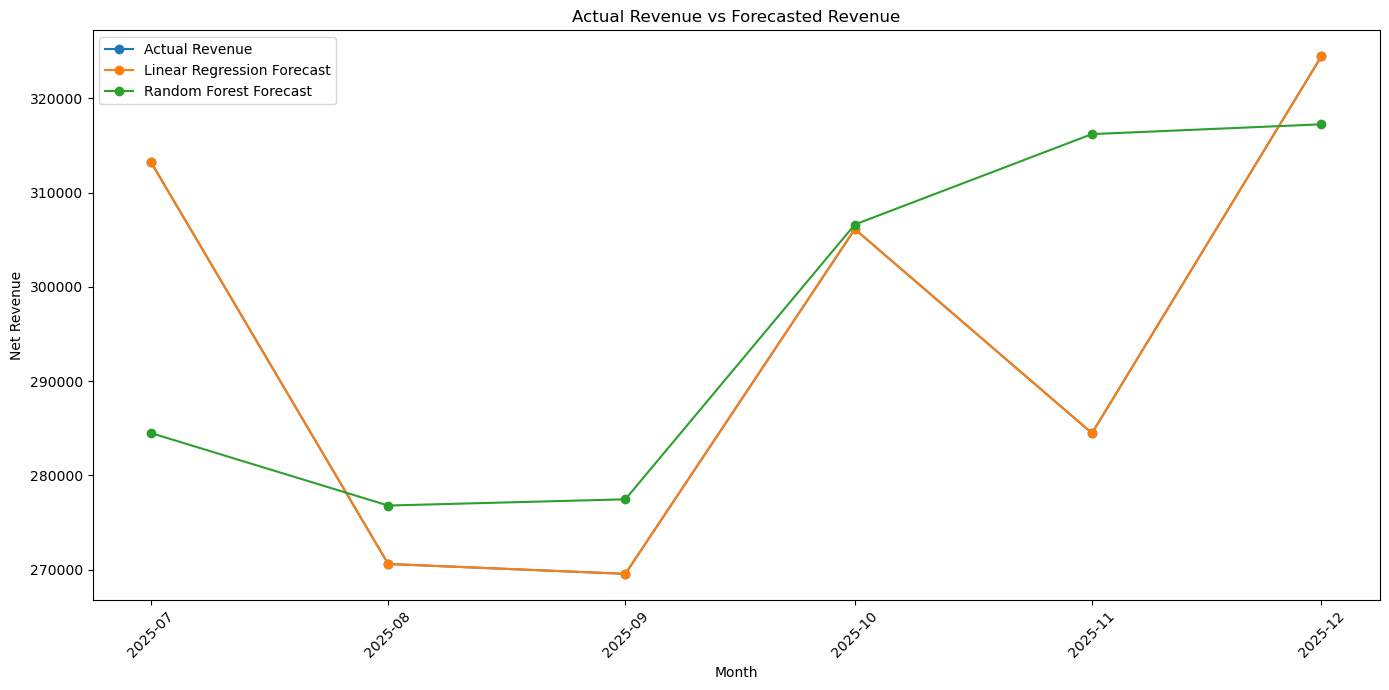

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/images/actual_vs_forecasted_revenue.png


In [16]:
# Visualize actual revenue compared to model forecasts

plt.figure(figsize=(14, 7))

plt.plot(
    forecast_comparison["order_month"],
    forecast_comparison["total_net_revenue"],
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    forecast_comparison["order_month"],
    forecast_comparison["linear_regression_forecast"],
    marker="o",
    label="Linear Regression Forecast"
)

plt.plot(
    forecast_comparison["order_month"],
    forecast_comparison["random_forest_forecast"],
    marker="o",
    label="Random Forest Forecast"
)

plt.title("Actual Revenue vs Forecasted Revenue")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

forecast_comparison_path = image_path / "actual_vs_forecasted_revenue.png"
plt.savefig(forecast_comparison_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", forecast_comparison_path)

In [17]:
# Create a future 6 month revenue forecast using Random Forest

last_row = monthly_sales.iloc[-1].copy()
future_forecast_rows = []

recent_revenues = list(monthly_sales["total_net_revenue"].tail(6))

for i in range(1, 7):
    future_month = last_row["order_month"] + pd.DateOffset(months=i)
    future_month_number = int(last_row["month_number"] + i)

    lag_1 = recent_revenues[-1]
    lag_2 = recent_revenues[-2]
    lag_3 = recent_revenues[-3]
    moving_avg_3 = np.mean(recent_revenues[-3:])
    moving_avg_6 = np.mean(recent_revenues[-6:])

    future_features = pd.DataFrame([{
        "month_number": future_month_number,
        "year": future_month.year,
        "month": future_month.month,
        "quarter": future_month.quarter,
        "revenue_3_month_moving_avg": moving_avg_3,
        "revenue_6_month_moving_avg": moving_avg_6,
        "revenue_lag_1": lag_1,
        "revenue_lag_2": lag_2,
        "revenue_lag_3": lag_3
    }])

    forecast_value = random_forest_model.predict(future_features)[0]

    future_forecast_rows.append({
        "forecast_month": future_month,
        "forecasted_net_revenue": round(forecast_value, 2)
    })

    recent_revenues.append(forecast_value)

future_forecast = pd.DataFrame(future_forecast_rows)

future_forecast

,forecast_month,forecasted_net_revenue
0,2026-01-01,256842.96
1,2026-02-01,261619.85
2,2026-03-01,259508.59
3,2026-04-01,262876.08
4,2026-05-01,263914.52
5,2026-06-01,268734.16


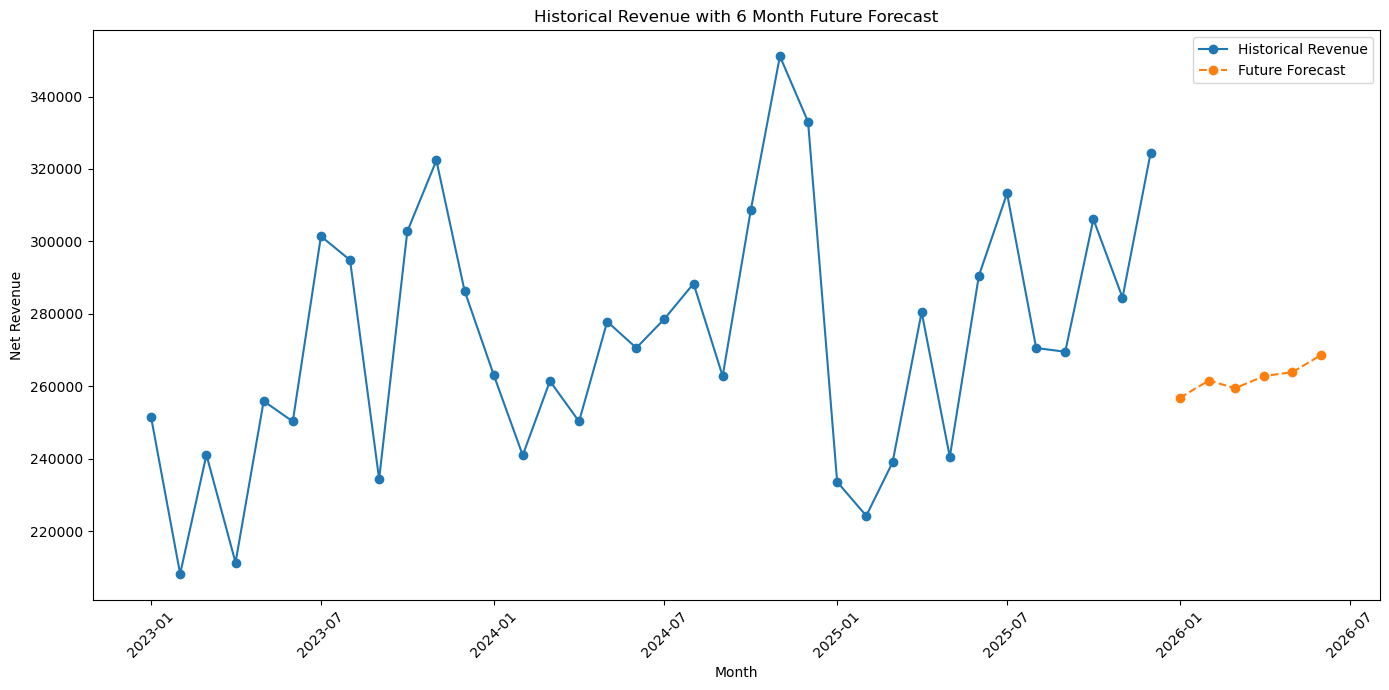

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/images/six_month_future_revenue_forecast.png


In [18]:
# Visualize historical revenue and future forecast

plt.figure(figsize=(14, 7))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["total_net_revenue"],
    marker="o",
    label="Historical Revenue"
)

plt.plot(
    future_forecast["forecast_month"],
    future_forecast["forecasted_net_revenue"],
    marker="o",
    linestyle="--",
    label="Future Forecast"
)

plt.title("Historical Revenue with 6 Month Future Forecast")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

future_forecast_path = image_path / "six_month_future_revenue_forecast.png"
plt.savefig(future_forecast_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", future_forecast_path)

In [19]:
# Save cleaned datasets and model outputs

monthly_sales_file = cleaned_path / "monthly_sales_summary.csv"
category_file = cleaned_path / "category_sales_summary.csv"
channel_file = cleaned_path / "channel_sales_summary.csv"
region_file = cleaned_path / "region_sales_summary.csv"
segment_file = cleaned_path / "segment_sales_summary.csv"
forecast_comparison_file = cleaned_path / "forecast_model_comparison.csv"
future_forecast_file = cleaned_path / "six_month_future_forecast.csv"
accuracy_file = cleaned_path / "forecast_accuracy_summary.csv"
seasonality_file = cleaned_path / "revenue_seasonality_matrix.csv"

monthly_sales.to_csv(monthly_sales_file, index=False)
category_summary.to_csv(category_file, index=False)
channel_summary.to_csv(channel_file, index=False)
region_summary.to_csv(region_file, index=False)
segment_summary.to_csv(segment_file, index=False)
forecast_comparison.to_csv(forecast_comparison_file, index=False)
future_forecast.to_csv(future_forecast_file, index=False)
accuracy_summary.to_csv(accuracy_file, index=False)
seasonality_matrix.to_csv(seasonality_file)

print("Files saved:")
print(monthly_sales_file)
print(category_file)
print(channel_file)
print(region_file)
print(segment_file)
print(forecast_comparison_file)
print(future_forecast_file)
print(accuracy_file)
print(seasonality_file)

Files saved:
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/cleaned/monthly_sales_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/cleaned/category_sales_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/cleaned/channel_sales_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/cleaned/region_sales_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/cleaned/segment_sales_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/cleaned/forecast_model_comparison.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/data/cleaned/six_month_future_forecast.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/02_Sales_Forecasting/da